In [5]:
import numpy as np
import scipy.signal as signal
from numpy.linalg import eigvals, matrix_power, matrix_rank
import scipy.linalg as la
import matplotlib.pyplot as plt

In [6]:
# ==========================================
# 1. T37 Vehicle Parameters (from vehicle_config.py)
# ==========================================
m = 210.0                           # Mass [kg]
L = 1.545                           # Wheelbase [m]
L_f = L / 2.0                       # CG to front axle [m] (0.7725)
L_r = L / 2.0                       # CG to rear axle [m] (0.7725)
C_alpha_f = 400.0 * (180.0 / np.pi) # Front cornering stiffness [N/rad] (~22918.3)
C_alpha_r = 400.0 * (180.0 / np.pi) # Rear cornering stiffness [N/rad] (~22918.3)
I_z = (1.0 / 12.0) * m * L**2       # Yaw moment of inertia [kg*m^2] (~41.77)
rho = 1.225                         # Air density [kg/m^3]
C_d = 0.35                          # Drag coefficient
A = 1.82                            # Frontal area [m^2]

# Nominal Operating Velocity
V = 10.0                            # m/s

Straight with constant velocity

In [7]:
# ==========================================
# 2. Build the Linear System Matrices (Straight Line)
# ==========================================
# A Matrix components
A11 = -rho * C_d * A * V / m
A22 = -(C_alpha_f + C_alpha_r) / (m * V)
A23 = -V + (C_alpha_r * L_r - C_alpha_f * L_f) / (m * V)
A32 = (C_alpha_r * L_r - C_alpha_f * L_f) / (I_z * V)
A33 = -(C_alpha_f * L_f**2 + C_alpha_r * L_r**2) / (I_z * V)

A_straight = np.array([
    [A11, 0,   0,   0, 0],
    [0,   A22, A23, 0, 0],
    [0,   A32, A33, 0, 0],
    [0,   1,   0,   0, V],
    [0,   0,   1,   0, 0]
])

B_straight = np.array([
    [1/m, 0],
    [0,   C_alpha_f / m],
    [0,   (L_f * C_alpha_f) / I_z],
    [0,   0],
    [0,   0]
])

# C Matrix for Observer Design (Assuming v_y is hidden)
# Output vector y = [e_vx, yaw_rate, e_y, e_psi]^T
C_obs = np.array([
    [1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1]
])

In [8]:
# ==========================================
# 3. Controllability Analysis
# ==========================================
print("--- Controllability Analysis ---")
# C = [B, AB, A^2B, A^3B, A^4B]
C_ctrl = np.hstack([
    B_straight,
    A_straight @ B_straight,
    matrix_power(A_straight, 2) @ B_straight,
    matrix_power(A_straight, 3) @ B_straight,
    matrix_power(A_straight, 4) @ B_straight
])

rank_C = matrix_rank(C_ctrl)
print(f"Rank of Controllability Matrix: {rank_C} (Expected: 5)")
if rank_C == 5:
    print("Result: System is FULLY CONTROLLABLE.")
else:
    print("Result: System is NOT fully controllable.")

--- Controllability Analysis ---
Rank of Controllability Matrix: 5 (Expected: 5)
Result: System is FULLY CONTROLLABLE.


In [9]:
# ==========================================
# 4. Observability Analysis
# ==========================================
print("\n--- Observability Analysis (Hidden v_y) ---")
# O = [C; CA; CA^2; CA^3; CA^4]
O_obs = np.vstack([
    C_obs,
    C_obs @ A_straight,
    C_obs @ matrix_power(A_straight, 2),
    C_obs @ matrix_power(A_straight, 3),
    C_obs @ matrix_power(A_straight, 4)
])

rank_O = matrix_rank(O_obs)
print(f"Rank of Observability Matrix: {rank_O} (Expected: 5)")
if rank_O == 5:
    print("Result: System is FULLY OBSERVABLE.")
    print("Conclusion: A Luenberger Observer or Kalman Filter can successfully estimate the hidden lateral velocity (v_y).")
else:
    print("Result: System is NOT fully observable.")


--- Observability Analysis (Hidden v_y) ---
Rank of Observability Matrix: 5 (Expected: 5)
Result: System is FULLY OBSERVABLE.
Conclusion: A Luenberger Observer or Kalman Filter can successfully estimate the hidden lateral velocity (v_y).


In [10]:
# ==========================================
# TEST CASE: Breaking Observability
# ==========================================
print("--- TEST CASE: Broken Observability ---")
print("Scenario: We lose the GPS cross-track error (e_y) sensor.")

# Broken observer: measuring e_vx, yaw_rate, e_psi (e_y is dropped!)
C_broken = np.array([
    [1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1]
])

O_broken = np.vstack([C_broken @ matrix_power(A_straight, i) for i in range(5)])
print(f"Rank: {matrix_rank(O_broken)}")
print("Conclusion: Rank has dropped to 4! Because the car is neutral steer, a pure lateral slide (v_y) creates no yaw rate. Without the e_y sensor to notice the car drifting off the path, the slide is mathematically invisible to the system.")

--- TEST CASE: Broken Observability ---
Scenario: We lose the GPS cross-track error (e_y) sensor.
Rank: 3
Conclusion: Rank has dropped to 4! Because the car is neutral steer, a pure lateral slide (v_y) creates no yaw rate. Without the e_y sensor to notice the car drifting off the path, the slide is mathematically invisible to the system.


In [11]:
# ==========================================
# Critical Speed (V_crit) Calculator
# ==========================================
print("--- Critical Speed Analysis ---")
moment_balance = C_alpha_f * L_f - C_alpha_r * L_r

if moment_balance <= 0:
    print("Result: V_crit is INFINITE.")
    print("Physics: The vehicle is neutral-steer or understeering. The rear stabilizing moment is greater than or equal to the front destabilizing moment.")
    print("Conclusion: The vehicle is unconditionally open-loop stable at all speeds.\n")
else:
    v_crit = np.sqrt((C_alpha_f * C_alpha_r * L**2) / (m * moment_balance))
    print(f"Result: V_crit is {v_crit:.2f} m/s")
    print("Physics: The vehicle is oversteering. Exceeding this speed will cause an unrecoverable spin.\n")

--- Critical Speed Analysis ---
Result: V_crit is INFINITE.
Physics: The vehicle is neutral-steer or understeering. The rear stabilizing moment is greater than or equal to the front destabilizing moment.
Conclusion: The vehicle is unconditionally open-loop stable at all speeds.



In [12]:
print("\n--- Parameter Sweep: CG Shift Instability ---")
cg_shifts = np.linspace(0.5, 0.6, 11)  # Sweeping L_f from 50% to 60% of wheelbase

for shift in cg_shifts:
    Lf_test = L * shift
    Lr_test = L * (1.0 - shift)
    moment_balance = C_alpha_f * Lf_test - C_alpha_r * Lr_test

    if moment_balance <= 0:
        print(f"CG at {shift*100:.1f}% front: V_crit is INFINITE (Stable)")
    else:
        v_crit = np.sqrt((C_alpha_f * C_alpha_r * L**2) / (m * moment_balance))
        print(f"CG at {shift*100:.1f}% front: V_crit drops to {v_crit:.2f} m/s (Unstable!)")


--- Parameter Sweep: CG Shift Instability ---
CG at 50.0% front: V_crit is INFINITE (Stable)
CG at 51.0% front: V_crit drops to 91.82 m/s (Unstable!)
CG at 52.0% front: V_crit drops to 64.93 m/s (Unstable!)
CG at 53.0% front: V_crit drops to 53.01 m/s (Unstable!)
CG at 54.0% front: V_crit drops to 45.91 m/s (Unstable!)
CG at 55.0% front: V_crit drops to 41.06 m/s (Unstable!)
CG at 56.0% front: V_crit drops to 37.48 m/s (Unstable!)
CG at 57.0% front: V_crit drops to 34.70 m/s (Unstable!)
CG at 58.0% front: V_crit drops to 32.46 m/s (Unstable!)
CG at 59.0% front: V_crit drops to 30.61 m/s (Unstable!)
CG at 60.0% front: V_crit drops to 29.04 m/s (Unstable!)


skidpad

In [13]:
# ==========================================
# 1. T37 Vehicle Parameters
# ==========================================
m = 210.0                           # Mass [kg]
L = 1.545                           # Wheelbase [m]
L_f = L / 2.0                       # CG to front
L_r = L / 2.0                       # CG to rear
C_alpha_f = 400.0 * (180.0 / np.pi) # Front cornering stiffness [N/rad]
C_alpha_r = 400.0 * (180.0 / np.pi) # Rear cornering stiffness [N/rad]
I_z = (1.0 / 12.0) * m * L**2       # Yaw moment of inertia
rho = 1.225                         # Air density
C_d = 0.35                          # Drag coefficient
A_front = 1.82                      # Frontal area

# Skidpad Operating Point
R_skidpad = 16.75                   # FSAE Skidpad radius [m]
kappa = 1.0 / R_skidpad             # Path curvature [1/m]
V = 3.0                             # Target velocity [m/s]

In [14]:
# ==========================================
# 2. Build A_skidpad (from our symbolic derivations)
# ==========================================
# Intermediate terms
A11 = -(A_front * C_d * rho * V) / m
A13 = (kappa * V * (C_alpha_r * L_f * L_r + C_alpha_r * L_r**2 - L_f * V**2 * m)) / (C_alpha_r * L)
A21 = (kappa * (C_alpha_f * C_alpha_r * L_f**2 + 2 * C_alpha_f * C_alpha_r * L_f * L_r + C_alpha_f * C_alpha_r * L_r**2 - C_alpha_f * L_f * V**2 * m - 2 * C_alpha_r * L_f * V**2 * m - C_alpha_r * L_r * V**2 * m)) / (C_alpha_r * V * m * L)
A22 = -(C_alpha_f + C_alpha_r) / (V * m)
A23 = (-C_alpha_f * L_f + C_alpha_r * L_r - V**2 * m) / (V * m)
A31 = (kappa * L_f * (C_alpha_f * C_alpha_r * L_f**2 + 2 * C_alpha_f * C_alpha_r * L_f * L_r + C_alpha_f * C_alpha_r * L_r**2 - C_alpha_f * L_f * V**2 * m + C_alpha_r * L_r * V**2 * m)) / (C_alpha_r * I_z * V * L)
A32 = (-C_alpha_f * L_f + C_alpha_r * L_r) / (I_z * V)
A33 = -(C_alpha_f * L_f**2 + C_alpha_r * L_r**2) / (I_z * V)

# Heading error at equilibrium (small angle approx)
v_y0 = V * (L_r * kappa - (m * L_f * V**2 * kappa) / (L * C_alpha_r))
e_psi0 = -v_y0 / V

A_skidpad = np.array([
    [A11, kappa * V, A13, 0, 0],
    [A21, A22,       A23, 0, 0],
    [A31, A32,       A33, 0, 0],
    [e_psi0, 1,      0,   0, V - v_y0 * e_psi0],
    [-kappa, 0,      1,   0, 0]
])

B_skidpad = np.array([
    [1/m, 0],
    [0,   C_alpha_f / m],
    [0,   (L_f * C_alpha_f) / I_z],
    [0,   0],
    [0,   0]
])

In [15]:
# ==========================================
# 3. Skidpad Theoretical Analysis
# ==========================================
print("--- 1. STABILITY (Skidpad Open-Loop Eigenvalues) ---")
eigenvalues = eigvals(A_skidpad)
for i, eig in enumerate(eigenvalues):
    print(f"Lambda_{i+1}: {eig:.4f}")

print("\n--- 2. CONTROLLABILITY ---")
C_ctrl = np.hstack([B_skidpad, A_skidpad @ B_skidpad, matrix_power(A_skidpad, 2) @ B_skidpad, matrix_power(A_skidpad, 3) @ B_skidpad, matrix_power(A_skidpad, 4) @ B_skidpad])
print(f"Rank of Controllability Matrix: {matrix_rank(C_ctrl)} (Expected: 5)")

print("\n--- 3. OBSERVABILITY (Hidden v_y) ---")
C_obs = np.array([
    [1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1]
])
O_obs = np.vstack([C_obs @ matrix_power(A_skidpad, i) for i in range(5)])
print(f"Rank of Observability Matrix: {matrix_rank(O_obs)} (Expected: 5)")

--- 1. STABILITY (Skidpad Open-Loop Eigenvalues) ---
Lambda_1: 0.0000
Lambda_2: 0.0000
Lambda_3: -218.2777
Lambda_4: -72.7633
Lambda_5: 0.0036

--- 2. CONTROLLABILITY ---
Rank of Controllability Matrix: 5 (Expected: 5)

--- 3. OBSERVABILITY (Hidden v_y) ---
Rank of Observability Matrix: 5 (Expected: 5)


In [16]:
print("\n--- Sweeping Velocity to find Stability Crossing ---")
velocities = np.linspace(1.0, 10.0, 5000)
crossing_velocity = None

for v_test in velocities:
    # 1. Re-evaluate equilibrium states for the current v_test
    v_y0_test = v_test * (L_r * kappa - (m * L_f * v_test**2 * kappa) / (L * C_alpha_r))
    e_psi0_test = -v_y0_test / v_test

    # 2. Recalculate intermediate A terms that depend on V
    A11_test = -(A_front * C_d * rho * v_test) / m
    A13_test = (kappa * v_test * (C_alpha_r * L_f * L_r + C_alpha_r * L_r**2 - L_f * v_test**2 * m)) / (C_alpha_r * L)
    A21_test = (kappa * (C_alpha_f * C_alpha_r * L_f**2 + 2 * C_alpha_f * C_alpha_r * L_f * L_r + C_alpha_f * C_alpha_r * L_r**2 - C_alpha_f * L_f * v_test**2 * m - 2 * C_alpha_r * L_f * v_test**2 * m - C_alpha_r * L_r * v_test**2 * m)) / (C_alpha_r * v_test * m * L)
    A22_test = -(C_alpha_f + C_alpha_r) / (v_test * m)
    A23_test = (-C_alpha_f * L_f + C_alpha_r * L_r - v_test**2 * m) / (v_test * m)
    A31_test = (kappa * L_f * (C_alpha_f * C_alpha_r * L_f**2 + 2 * C_alpha_f * C_alpha_r * L_f * L_r + C_alpha_f * C_alpha_r * L_r**2 - C_alpha_f * L_f * v_test**2 * m + C_alpha_r * L_r * v_test**2 * m)) / (C_alpha_r * I_z * v_test * L)
    A32_test = (-C_alpha_f * L_f + C_alpha_r * L_r) / (I_z * v_test)
    A33_test = -(C_alpha_f * L_f**2 + C_alpha_r * L_r**2) / (I_z * v_test)

    # 3. Rebuild the matrix
    A_test = np.array([
        [A11_test, kappa * v_test, A13_test, 0, 0],
        [A21_test, A22_test,       A23_test, 0, 0],
        [A31_test, A32_test,       A33_test, 0, 0],
        [e_psi0_test, 1,           0,        0, v_test - v_y0_test * e_psi0_test],
        [-kappa,   0,              1,        0, 0]
    ])

    # 4. Extract eigenvalues, ignoring the pure integrators (~0)
    eigs = np.linalg.eigvals(A_test)
    dynamic_eigs = [e.real for e in eigs if abs(e.real) > 1e-4]

    # Check if the maximum real part has crossed into the negatives
    if max(dynamic_eigs) < 0:
        crossing_velocity = v_test
        break

if crossing_velocity:
    print(f"Result: The Skidpad drift mode becomes naturally stable at V = {crossing_velocity:.2f} m/s")
else:
    print("Result: No stability crossing found in this sweep range.")


--- Sweeping Velocity to find Stability Crossing ---
Result: The Skidpad drift mode becomes naturally stable at V = 5.21 m/s


accel

--- Acceleration Event (LTV) Eigenvalue Migration ---


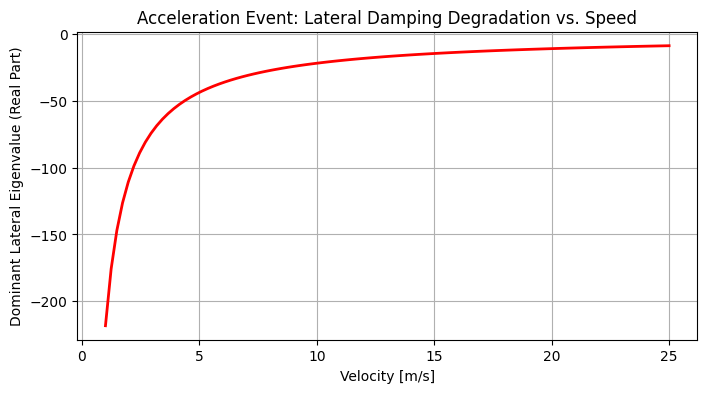

In [17]:
print("--- Acceleration Event (LTV) Eigenvalue Migration ---")
velocities_accel = np.linspace(1.0, 25.0, 100)
damping_history = []

for v_test in velocities_accel:
    # Build the decoupled LTV A_matrix for the current velocity
    A11 = -rho * C_d * A * v_test / m
    A22 = -(C_alpha_f + C_alpha_r) / (m * v_test)
    A23 = -v_test + (C_alpha_r * L_r - C_alpha_f * L_f) / (m * v_test)
    A32 = (C_alpha_r * L_r - C_alpha_f * L_f) / (I_z * v_test)
    A33 = -(C_alpha_f * L_f**2 + C_alpha_r * L_r**2) / (I_z * v_test)

    A_accel = np.array([
        [A11, 0,   0,   0, 0],
        [0,   A22, A23, 0, 0],
        [0,   A32, A33, 0, 0],
        [0,   1,   0,   0, v_test],
        [0,   0,   1,   0, 0]
    ])

    # Extract eigenvalues and find the dominant lateral poles
    eigs = np.linalg.eigvals(A_accel)
    # Filter out the pure integrators and longitudinal mode
    lat_eigs = [e.real for e in eigs if abs(e.real) > 1e-4 and abs(e.real - A11) > 1e-4]

    if lat_eigs:
        # The least negative eigenvalue dictates the system's slowest damping
        damping_history.append(max(lat_eigs))
    else:
        damping_history.append(0)

# Optional: Plot the degradation (Great for the presentation!)
plt.figure(figsize=(8, 4))
plt.plot(velocities_accel, damping_history, linewidth=2, color='red')
plt.title("Acceleration Event: Lateral Damping Degradation vs. Speed")
plt.xlabel("Velocity [m/s]")
plt.ylabel("Dominant Lateral Eigenvalue (Real Part)")
plt.grid(True)
plt.show()

LQR

In [18]:
# ==========================================
# 1. Define the System (Straight Line Baseline)
# ==========================================
m = 210.0; L = 1.545; L_f = L/2.0; L_r = L/2.0
C_alpha_f = 400.0 * (180.0 / np.pi); C_alpha_r = 400.0 * (180.0 / np.pi)
I_z = (1.0 / 12.0) * m * L**2; rho = 1.225; C_d = 0.35; A_front = 1.82
V = 10.0 # m/s

A11 = -rho * C_d * A_front * V / m
A22 = -(C_alpha_f + C_alpha_r) / (m * V)
A23 = -V + (C_alpha_r * L_r - C_alpha_f * L_f) / (m * V)
A32 = (C_alpha_r * L_r - C_alpha_f * L_f) / (I_z * V)
A33 = -(C_alpha_f * L_f**2 + C_alpha_r * L_r**2) / (I_z * V)

A_straight = np.array([
    [A11, 0,   0,   0, 0],
    [0,   A22, A23, 0, 0],
    [0,   A32, A33, 0, 0],
    [0,   1,   0,   0, V],
    [0,   0,   1,   0, 0]
])

B_straight = np.array([
    [1/m, 0],
    [0,   C_alpha_f / m],
    [0,   (L_f * C_alpha_f) / I_z],
    [0,   0],
    [0,   0]
])

In [19]:
# ==========================================
# 2. Bryson's Rule Tuning
# ==========================================
# Max acceptable states: e_vx=1.0, v_y=0.5, yaw_rate=0.5, e_y=0.5, e_psi=0.25
Q = np.diag([1/(1.0**2), 1/(0.5**2), 1/(0.5**2), 1/(0.5**2), 1/(0.25**2)])

# Max acceptable inputs: F_x=1500 N, delta=0.35 rad
R = np.diag([1/(1500.0**2), 1/(0.35**2)])

print("--- LQR Tuning Matrices ---")
print("Q Matrix:\n", np.round(Q, 2))
print("\nR Matrix:\n", np.format_float_scientific(R[0,0], exp_digits=2), "  0")
print(" 0             ", np.round(R[1,1], 2))

--- LQR Tuning Matrices ---
Q Matrix:
 [[ 1.  0.  0.  0.  0.]
 [ 0.  4.  0.  0.  0.]
 [ 0.  0.  4.  0.  0.]
 [ 0.  0.  0.  4.  0.]
 [ 0.  0.  0.  0. 16.]]

R Matrix:
 4.4444444444444444e-07   0
 0              8.16


In [20]:
# ==========================================
# 3. Solve the Algebraic Riccati Equation
# ==========================================
# P is the solution to the ARE
P = la.solve_continuous_are(A_straight, B_straight, Q, R)

# Calculate the Optimal Gain Matrix K
K = la.inv(R) @ B_straight.T @ P

print("\n--- Optimal Feedback Gain Matrix (K) ---")
np.set_printoptions(suppress=True, precision=4)
print(K)


--- Optimal Feedback Gain Matrix (K) ---
[[1492.217    -0.        0.       -0.       -0.    ]
 [  -0.        0.1736    0.5518    0.7       3.3381]]


In [21]:
# ==========================================
# 4. Verify Closed-Loop Stability
# ==========================================
# The closed-loop dynamics are (A - B*K)
A_closed_loop = A_straight - B_straight @ K
cl_eigs = la.eigvals(A_closed_loop)

print("\n--- Closed-Loop Eigenvalues (A - BK) ---")
for i, eig in enumerate(cl_eigs):
    print(f"Lambda_{i+1}: {eig.real:.4f} + {eig.imag:.4f}j")

# Check if all real parts are negative
if all(eig.real < 0 for eig in cl_eigs):
    print("\nResult: SUCCESS! The LQR controller has stabilized the system.")
else:
    print("\nResult: FAILED. The system is still unstable.")


--- Closed-Loop Eigenvalues (A - BK) ---
Lambda_1: -7.1430 + 0.0000j
Lambda_2: -313.2468 + 0.0000j
Lambda_3: -2.3607 + 1.9396j
Lambda_4: -2.3607 + -1.9396j
Lambda_5: -22.1450 + 0.0000j

Result: SUCCESS! The LQR controller has stabilized the system.


sweeping V and kappa for LQR

--- Executing 2D LQR Gain Scheduling Sweep ---


<>:87: SyntaxWarning: invalid escape sequence '\k'
<>:87: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_19794/3801072754.py:87: SyntaxWarning: invalid escape sequence '\k'
  plt.xlabel('Path Curvature $\kappa$ [rad/m]')


Sweep Complete. Grid size: 625 nodes.
Result: ALL nodes successfully stabilized. The Gain Scheduling LuT is mathematically robust!


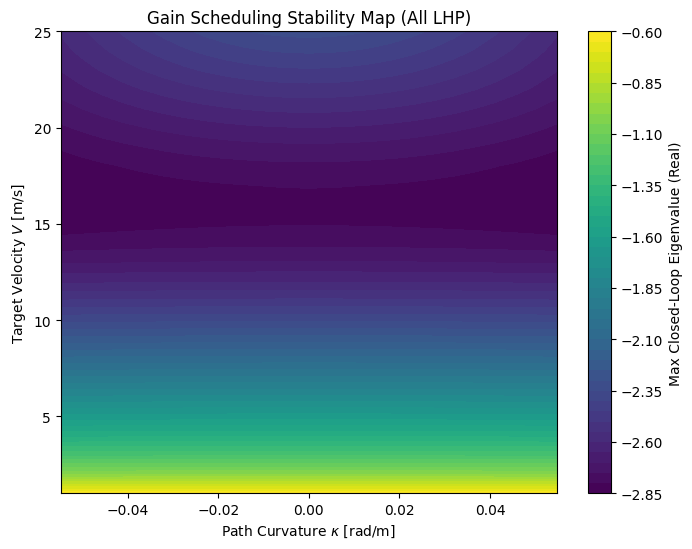

In [22]:
# ==========================================
# 1. T37 Vehicle Parameters & Tuning
# ==========================================
m = 210.0; L = 1.545; L_f = L/2.0; L_r = L/2.0
C_alpha_f = 400.0 * (180.0 / np.pi); C_alpha_r = 400.0 * (180.0 / np.pi)
I_z = (1.0 / 12.0) * m * L**2; rho = 1.225; C_d = 0.35; A_front = 1.82

# Bryson's Rule Weights
Q = np.diag([1/(1.0**2), 1/(0.5**2), 1/(0.5**2), 1/(0.5**2), 1/(0.25**2)])
R = np.diag([1/(1500.0**2), 1/(0.35**2)])

B = np.array([
    [1/m, 0],
    [0,   C_alpha_f / m],
    [0,   (L_f * C_alpha_f) / I_z],
    [0,   0],
    [0,   0]
])

# ==========================================
# 2. Define the 2D Sweep Grid
# ==========================================
# Sweep Velocity from 1 to 25 m/s
v_range = np.linspace(1.0, 25.0, 25)
# Sweep Curvature from -1/18.25 (Right) to 1/18.25 (Left)
kappa_range = np.linspace(-1/18.25, 1/18.25, 25)

# Storage for plotting the worst-case eigenvalue stability
stability_map = np.zeros((len(v_range), len(kappa_range)))

print("--- Executing 2D LQR Gain Scheduling Sweep ---")
failed_points = 0

for i, v in enumerate(v_range):
    for j, k in enumerate(kappa_range):

        # 1. Calculate Equilibrium States
        v_y0 = v * (L_r * k - (m * L_f * v**2 * k) / (L * C_alpha_r))
        e_psi0 = -v_y0 / v

        # 2. Build A Matrix for this (V, kappa)
        A11 = -(A_front * C_d * rho * v) / m
        A13 = (k * v * (C_alpha_r * L_f * L_r + C_alpha_r * L_r**2 - L_f * v**2 * m)) / (C_alpha_r * L)
        A21 = (k * (C_alpha_f * C_alpha_r * L_f**2 + 2 * C_alpha_f * C_alpha_r * L_f * L_r + C_alpha_f * C_alpha_r * L_r**2 - C_alpha_f * L_f * v**2 * m - 2 * C_alpha_r * L_f * v**2 * m - C_alpha_r * L_r * v**2 * m)) / (C_alpha_r * v * m * L)
        A22 = -(C_alpha_f + C_alpha_r) / (v * m)
        A23 = (-C_alpha_f * L_f + C_alpha_r * L_r - v**2 * m) / (v * m)
        A31 = (k * L_f * (C_alpha_f * C_alpha_r * L_f**2 + 2 * C_alpha_f * C_alpha_r * L_f * L_r + C_alpha_f * C_alpha_r * L_r**2 - C_alpha_f * L_f * v**2 * m + C_alpha_r * L_r * v**2 * m)) / (C_alpha_r * I_z * v * L)
        A32 = (-C_alpha_f * L_f + C_alpha_r * L_r) / (I_z * v)
        A33 = -(C_alpha_f * L_f**2 + C_alpha_r * L_r**2) / (I_z * v)

        A = np.array([
            [A11, k * v, A13, 0, 0],
            [A21, A22,   A23, 0, 0],
            [A31, A32,   A33, 0, 0],
            [e_psi0, 1,    0, 0, v - v_y0 * e_psi0],
            [-k,  0,       1, 0, 0]
        ])

        # 3. Solve CARE for Optimal K
        try:
            P = la.solve_continuous_are(A, B, Q, R)
            K = la.inv(R) @ B.T @ P

            # 4. Check Closed-Loop Eigenvalues
            A_cl = A - B @ K
            max_eig = np.max(np.real(la.eigvals(A_cl)))
            stability_map[i, j] = max_eig

            if max_eig >= 0:
                failed_points += 1

        except la.LinAlgError:
            failed_points += 1
            stability_map[i, j] = np.nan

print(f"Sweep Complete. Grid size: {len(v_range) * len(kappa_range)} nodes.")
if failed_points == 0:
    print("Result: ALL nodes successfully stabilized. The Gain Scheduling LuT is mathematically robust!")
else:
    print(f"Result: {failed_points} nodes failed to stabilize. Tuning required.")

# Optional: Visualize the stability map
plt.figure(figsize=(8, 6))
plt.contourf(kappa_range, v_range, stability_map, levels=50, cmap='viridis')
plt.colorbar(label='Max Closed-Loop Eigenvalue (Real)')
plt.title('Gain Scheduling Stability Map (All LHP)')
plt.xlabel('Path Curvature $\kappa$ [rad/m]')
plt.ylabel('Target Velocity $V$ [m/s]')
plt.show()

## Creating Observer

In [25]:
## Calculate L for observer dynamics

cl_eigs_observer = cl_eigs * 5  # Place observer poles 5x faster than controller poles
L_luenberger  = signal.place_poles(A_straight.T, C_obs.T, cl_eigs_observer).gain_matrix.T
print("Observer Gain Matrix (L_luenberger):\n", np.round(L_luenberger, 4))   

## Calculate Kalman Filter Gain (L_kalman)
# Assume process noise covariance (Q_kalman) and measurement noise covariance (R_kalman)
Q_kalman = np.diag([0.1, 0.1, 0.1, 0.1, 0.1])  # Process noise covariance
R_kalman = np.diag([0.01, 0.01, 0.01, 0.01])  # Measurement noise covariance    
P_kalman = la.solve_continuous_are(A_straight.T, C_obs.T, Q_kalman, R_kalman)
L_kalman = P_kalman @ C_obs.T @ la.inv(R_kalman)
print("\nKalman Filter Gain Matrix (L_kalman):\n", np.round(L_kalman, 4))


## Analyze Observer Eigenvalues
A_observer = A_straight - L_luenberger @ C_obs
observer_eigs = la.eigvals(A_observer)
print("\nObserver Eigenvalues (A - LC):")
for i, eig in enumerate(observer_eigs):
    print(f"Lambda_{i+1}: {eig.real:.4f} + {eig.imag:.4f}j")

A_kalman_observer = A_straight - L_kalman @ C_obs
kalman_observer_eigs = la.eigvals(A_kalman_observer)
print("\nKalman Observer Eigenvalues (A - L_kalman C):")
for i, eig in enumerate(kalman_observer_eigs):
    print(f"Lambda_{i+1}: {eig.real:.4f} + {eig.imag:.4f}j")    

Observer Gain Matrix (L_luenberger):
 [[  16.5591    6.3215   17.5429    6.3215]
 [-123.328    -0.7297  -84.2289    9.2703]
 [   6.3539  772.5716   -1.4015 -728.1817]
 [  -0.0156   -0.1653   21.7528    9.8347]
 [   6.3539 -727.1817   -1.4015  838.0526]]

Kalman Filter Gain Matrix (L_kalman):
 [[ 3.1253 -0.     -0.      0.    ]
 [ 0.     -0.0087  0.0076 -0.0016]
 [-0.      0.0763 -0.      0.0011]
 [-0.     -0.      7.1401  2.3166]
 [ 0.      0.0011  2.3166  2.153 ]]

Observer Eigenvalues (A - LC):
Lambda_1: -110.7251 + 0.0000j
Lambda_2: -35.7148 + 0.0000j
Lambda_3: -11.8035 + 9.6981j
Lambda_4: -11.8035 + -9.6981j
Lambda_5: -1566.2342 + 0.0000j

Kalman Observer Eigenvalues (A - L_kalman C):
Lambda_1: -3.1625 + 0.0000j
Lambda_2: -21.8265 + 0.0000j
Lambda_3: -4.6468 + 3.4031j
Lambda_4: -4.6468 + -3.4031j
Lambda_5: -65.5572 + 0.0000j
